Luis Amadis Madrigal

Goal: Predict Telco Churn

Import Pandas to start

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Telco_Churn_Data.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Exploratory data analysis

In [5]:
# Rows/Columns
df.shape
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
# Make sure that all of my columns are the correct data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
# Any NA values
df.isna().sum() # No null values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Any duplicates

In [8]:
df.duplicated().sum() # No duplicates

0

In [9]:
### IN THIS SECTION WE AE GOING TO DO EXPLORATORY DATA ANALYSIS BY ANSWERING CERTAIN QUESTIONS AND VISUALIZING THEM
import seaborn as sns
import matplotlib.pyplot as plt

Of the customers that churned what was their average tenure

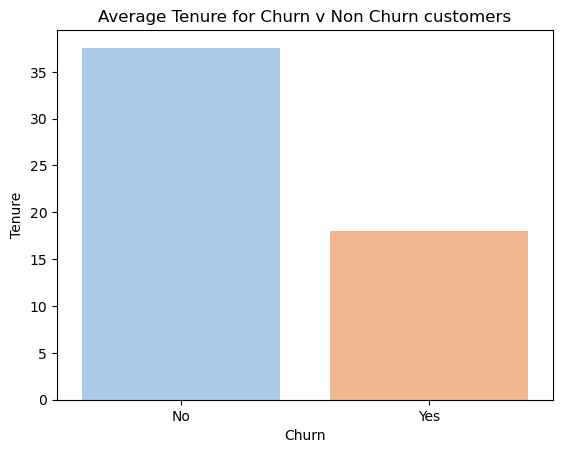

In [10]:
avg_tenure = df.groupby('Churn')[['tenure']].mean()
sns.barplot(data = avg_tenure, x = "Churn", y= "tenure", hue = 'Churn', palette = 'pastel')
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.title("Average Tenure for Churn v Non Churn customers")
plt.show()
# The average tenure that people that didnt churn had were 37 months(around 3 years)
# On the other hand, the average tenure of people that did churn were 18 months(aroudn a year and a half)

In [11]:
# The monthly charges of customers that churned
churned = df[df['Churn'] == 'Yes']
churned['MonthlyCharges'].mean() # montly charges were $74

74.44133226324237

In [12]:
# Monthly charges of customers that didnt churn
didntchurn = df[df['Churn'] == 'No']
didntchurn['MonthlyCharges'].mean() # Monthly charges were $61

61.26512369540008

In [13]:
churn_charges = df.groupby('Churn')[['MonthlyCharges']].mean()

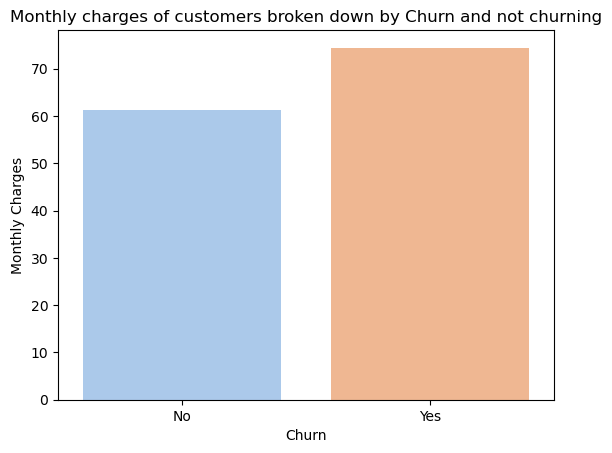

In [14]:
sns.barplot(data = churn_charges, x = 'Churn', y= 'MonthlyCharges', hue = 'Churn', palette = 'pastel')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.title('Monthly charges of customers broken down by Churn and not churning')
plt.show()
# Customers that churned had a higher bill than the ones that didnt
# That was probably a factor that contributed to them churning

Did the types of contract had anything to do with the churning occuring?

In [15]:
type_contract = df.groupby(['Contract', 'Churn'])[['Churn']].count()
type_contract
# This displayed that the longer that a contract plan was, the less likely it was for the customer to churn
# Of the 3875 customers who had a month to month plan, 1655 churned. While of the 1695 customers who had a two year contract, only 48 churned

Churn
Contract       Churn       
Month-to-month No      2220
               Yes     1655
One year       No      1307
               Yes      166
Two year       No      1647
               Yes       48

In [16]:
# What is the gender distribution of people that churned
churned = df[df['Churn'] == 'Yes']
gen_churn= churned.groupby('gender')[['Churn']].count()
gen_churn

,Churn
gender,
Female,939
Male,930


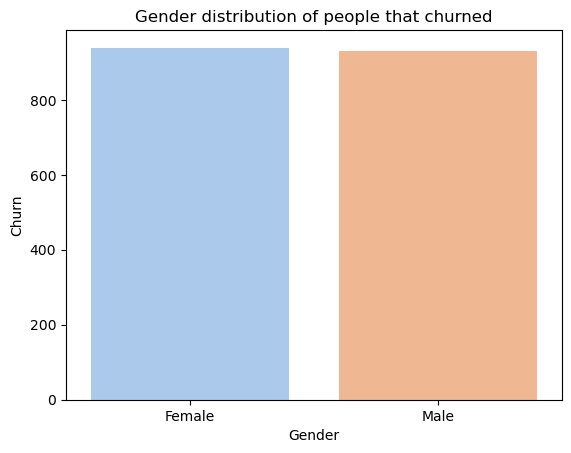

In [17]:
sns.barplot(data= gen_churn, x= 'gender', y= 'Churn', hue= 'gender', palette='pastel')
plt.xlabel('Gender')
plt.ylabel('Churn')
plt.title('Gender distribution of people that churned')
plt.show()

There were 939 Females and 930 males that churned so gender and churning dont really have a strong correlation

MODEL CREATION

First we are going to try a simple decision tree

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

Lets create a new df 

In [19]:
dtree = df.copy()

So lets first drop select the features that will not be needed and we will drop

In [20]:
dtree = dtree.drop(columns=['customerID', 'Partner', 'Dependents', 'PaperlessBilling'])

Features

In [21]:
features = dtree.loc[:, dtree.columns != 'Churn']

Label

In [22]:
labels = dtree['Churn']

Alot of these categories are categorical so we have to one hot encode these columns

In [23]:
features = pd.get_dummies(features)
features.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Female',
       'gender_Male', 'PhoneService_No', 'PhoneService_Yes',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes',
       ...
       'TotalCharges_995.35', 'TotalCharges_996.45', 'TotalCharges_996.85',
       'TotalCharges_996.95', 'TotalCharges_997.65', 'TotalCharges_997.75',
       'TotalCharges_998.1', 'TotalCharges_999.45', 'TotalCharges_999.8',
       'TotalCharges_999.9'],
      dtype='object', length=6569)

Train Test Split the Training and Testing Data

In [24]:
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.3)

Create an untrained model

In [25]:
model = DecisionTreeClassifier()

In [26]:
# Train the model on the training set(.70)
model.fit(features_train, labels_train)

DecisionTreeClassifier()

Compute the training accuracy

In [27]:
train_predictions = model.predict(features_train)
print("Training Accuracy", accuracy_score(labels_train, train_predictions))

Training Accuracy 0.996551724137931


In [28]:
test_predictions = model.predict(features_test)
print("Test_Accuracy", accuracy_score(labels_test, test_predictions))

Test_Accuracy 0.7605300520586843


Training Accuracy came out to .99

Test Accuracy came out to .76

My model is clearly overfitting since its memorizing the training data way too well.
Its not generalizing terribly since the testing accuracy is a .76 but it can definitely be better.

I will now create a confusion matrix to see exactly how the model is performing.

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [30]:
confusionmatrix = confusion_matrix(labels_test, test_predictions)

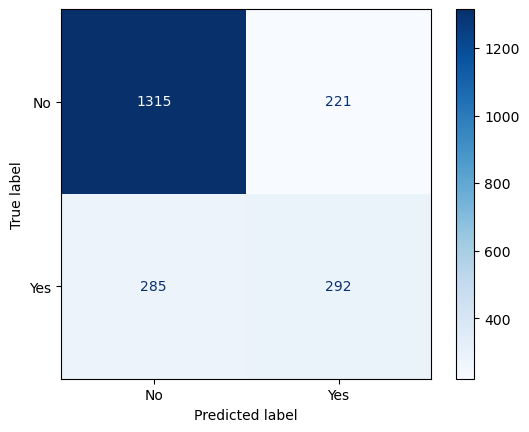

In [31]:
cm1 = ConfusionMatrixDisplay(confusion_matrix=confusionmatrix, display_labels= model.classes_)
cm1.plot(cmap="Blues")
plt.show()

So all in all, this confusion matrix is doing a pretty decent job in predicting who is churning. The area where
its having its biggest issues is in the areas where the model is predicting that a customer is not going to churn but in
reality that customer is actually churning. This is a bit bad since we wont be able to target these customers with extra promotions
since my model is predicting that they arent going to churn. I would be comfortable with a test score a bit higher probably atleast over 90%.

In [32]:
# Lets create a classfication report to see the Precision, Recall etc.
from sklearn.metrics import classification_report
print(classification_report(labels_test, test_predictions))

              precision    recall  f1-score   support

          No       0.82      0.86      0.84      1536
         Yes       0.57      0.51      0.54       577

    accuracy                           0.76      2113
   macro avg       0.70      0.68      0.69      2113
weighted avg       0.75      0.76      0.76      2113



For churn projects 'recall' is one if not the most important metric because you want to correctly identify the customers
who are potentially going to churn or not so you know if you want to target them with extra promotions etc. 
Well for this model my recall for no was .86 while my recall for yes was .51. 
It seems as the model is having difficulty actually identifying the potential churners but doing pretty well identifying people that are not going to churn.
This means that we are losing 49% of potential churners without ever identifying them. This can lead to a lot of lost money since there will be no retention efforts towards these individuals.

MODEL 2
Now we are creating a second model but this one is going to be a Random Forest

In [33]:
# Lets import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [34]:
# Create a new dataframe for this model
rf = df.copy()

In [35]:
rf.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [36]:
# Drop columns that I dont want to include in my random forest
rf = rf.drop(columns=['customerID', 'Partner', 'Dependents', 'PaperlessBilling',])

In [37]:
# Features 
rf_features = rf.loc[:, rf.columns != 'Churn']

In [38]:
# Labels 
rf_labels = rf['Churn']

In [39]:
# Since its also a classification model, lets one hot encode the features
rf = pd.get_dummies(rf_features)

In [40]:
# Train Test Split the data
rf_features_train, rf_features_test, rf_labels_train, rf_labels_test = train_test_split(features, labels, test_size=0.3)

In [41]:
# Lets create the untrained model
random_forest = RandomForestClassifier()

In [42]:
# Train the model with the training set
random_forest.fit(rf_features_train, rf_labels_train)

RandomForestClassifier()

In [43]:
# Predictions
random_forest_predictions = random_forest.predict(rf_features_train)
random_forest_test_predictions = random_forest.predict(rf_features_test)

Compute Training Accuracy

In [44]:
print("Training Accuracy", accuracy_score(rf_labels_train, random_forest_predictions))

Training Accuracy 0.9963488843813387


Compute the test accuracy

In [45]:
random_forest_test_predictions = random_forest.predict(rf_features_test)
print("Testing Accuracy", accuracy_score(rf_labels_test, random_forest_test_predictions))

Testing Accuracy 0.7832465688594415


The training accuracy for my random forest model came out to .997
The testing accuracy for my random forest model came out to .791
My model is slightly overfitting but the testing accuracy jumped from 61%
on the Decision Tree model to 78% on this one.

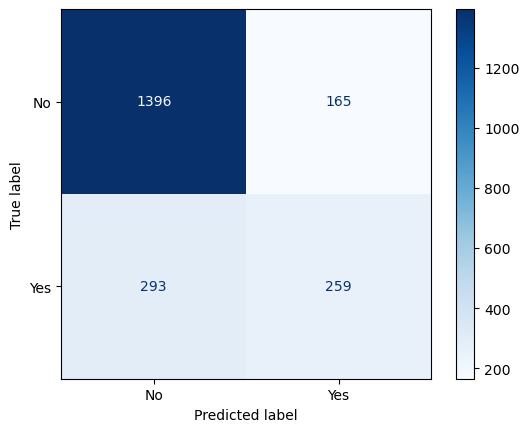

In [46]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(rf_labels_test, random_forest_test_predictions, labels=random_forest.classes_)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=random_forest.classes_)
disp1.plot(cmap= 'Blues')

In [47]:
# Classification report
print(classification_report(rf_labels_test, random_forest_test_predictions))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1561
         Yes       0.61      0.47      0.53       552

    accuracy                           0.78      2113
   macro avg       0.72      0.68      0.69      2113
weighted avg       0.77      0.78      0.77      2113



The recall for Yes is very low(.47) but for No its a .89. As stated beforehand, this is something 
that in the real world would be a problem because we arent accurately pointing out the people that are going to churn
so we cant really target them